In [44]:
import pickle
import numpy as np
import os
import sys
import plotly.graph_objs as go
import matplotlib.pyplot as plt

path = os.getcwd().split(os.sep +'GUI')[0]
if path not in sys.path:
    sys.path.append(path)

import neurolib.dashboard.layout as layout
import neurolib.dashboard.functions as functions
import neurolib.dashboard.data as data

In [45]:
# plot and save for all data points
from neurolib.models.aln import ALNModel
from neurolib.utils import plotFunctions as plotFunc
from neurolib.utils import costFunctions as cost
import os

path = os.path.join(os.getcwd(), "plots_")

aln = ALNModel()
data.set_parameters(aln)

state_vars = aln.state_vars

In [46]:
##### LOAD BOUNDARIES
with open('boundary_bi.pickle','rb') as file:
    load_array= pickle.load(file)
boundary_bi_exc = load_array[0]
boundary_bi_inh = load_array[1]

with open('boundary_LC.pickle','rb') as file:
    load_array= pickle.load(file)
boundary_LC_exc = load_array[0]
boundary_LC_inh = load_array[1]

with open('boundary_LCbi.pickle','rb') as file:
    load_array= pickle.load(file)
boundary_LC_up_exc = load_array[0]
boundary_LC_up_inh = load_array[1]

In [53]:
def setcase(obj, active):
    set_case(case)

def set_case(old_case):
    b0 = button0.active
    b1 = button1.active
    b2 = button2.active
    b3 = button3.active
    b4 = button4.active
    #b5 = button5.active
    case_ = str(b0) + str(b1) + str(b2) + str(b3) + str(b4) #+ str(b5)    
    
    functions.setdefaultmarkersize(layout.markersize, scatter1)
    functions.setdefaultmarkersize(layout.markersize, scatter2)
    functions.setdefaultmarkersize(layout.markersize, scatter3)
    functions.setdefaultmarkersize(layout.markersize, scatter4)
    
    global exc_, inh_, no_c_, both_c_
    global exc_1, inh_1, lenx_1, leny_1, exc_2, inh_2, lenx_2, leny_2
    global exc_3, inh_3, lenx_3, leny_3, exc_4, inh_4, lenx_4, leny_4, cost1, cost2, cost3, cost4
    global img_path
    
    
    #print("switch case to ", case_)
    fig.layout.annotations = fig.layout.annotations[:9]
    fig.layout.images = []
    
    global case
    case = case_
    casepath = case[0] + case[1] + '1' + case[3] + case[4]
    
    readpath = '.' + os.sep + 'data' + os.sep + casepath + os.sep
    data_array = data.read_data(readpath, case_)
    exc_, inh_, both_c_, no_c_ = data_array[0:4]
    exc_1, inh_1, lenx_1, leny_1, exc_2, inh_2, lenx_2, leny_2 = data_array[4:12]
    exc_3, inh_3, lenx_3, leny_3, exc_4, inh_4, lenx_4, leny_4, cost1, cost2, cost3, cost4 = data_array[12:]
    data.update_data(fig, exc_1, inh_1, exc_2, inh_2, exc_3, inh_3, exc_4, inh_4)
        
    img_path = set_image_path(case_)
        
    return [case_, img_path, exc_, inh_, no_c_, both_c_,
                exc_1, inh_1, lenx_1, leny_1, exc_2, inh_2, lenx_2, leny_2,
                exc_3, inh_3, lenx_3, leny_3, exc_4, inh_4, lenx_4, leny_4, cost1, cost2, cost3, cost4]
        
def set_image_path(str_case):
    img_path_ = 'plots_' + os.sep + str_case + os.sep
    return img_path_
    
def show_trace(trace, points, state):
    ind = points.point_inds
    
    if len(ind) == 0:
        return
        
    functions.setdefaultmarkersize(0, trace)
    functions.setmarkersize(ind[-1], layout.background_markersize, trace)
    functions.setdefaultmarkersize(layout.markersize, scatter1)
    functions.setdefaultmarkersize(layout.markersize, scatter2)
    functions.setdefaultmarkersize(layout.markersize, scatter3)
    functions.setdefaultmarkersize(layout.markersize, scatter4)

    data.plot_trace(aln, data_background.x[ind[-1]], data_background.y[ind[-1]], fig.data[7], fig.data[8])
    
def show_arrow_and_traces(trace, points, state):
    ind = points.point_inds
    
    if len(ind) == 0:
        return
        
    functions.setdefaultmarkersize(0, scatter_background)
    for tr in fig.data[1:5]:
        functions.setdefaultmarkersize(layout.markersize, tr)
    functions.setmarkersize(ind[-1], 2. * layout.markersize, trace)
    
    fig.layout.annotations = fig.layout.annotations[:9]
    
    if trace.uid == '1':
        fig.layout.annotations[8].text = layout.change_cost_layout(cost1[ind[-1]], case)
        e_, i_, lx_, ly_ = exc_1[ind[-1]], inh_1[ind[-1]], lenx_1[ind[-1]], leny_1[ind[-1]]
    elif trace.uid == '2':
        fig.layout.annotations[8].text = layout.change_cost_layout(cost2[ind[-1]], case)
        e_, i_, lx_, ly_ = exc_2[ind[-1]], inh_2[ind[-1]], lenx_2[ind[-1]], leny_2[ind[-1]]
    elif trace.uid == '3':
        fig.layout.annotations[8].text = layout.change_cost_layout(cost3[ind[-1]], case)
        e_, i_, lx_, ly_ = exc_3[ind[-1]], inh_3[ind[-1]], lenx_3[ind[-1]], leny_3[ind[-1]]
    elif trace.uid == '4':
        fig.layout.annotations[8].text = layout.change_cost_layout(cost4[ind[-1]], case)
        e_, i_, lx_, ly_ = exc_4[ind[-1]], inh_4[ind[-1]], lenx_4[ind[-1]], leny_4[ind[-1]]                                                                                
    
    data.plot_trace(aln, e_, i_, fig.data[7], fig.data[8])
    
    if trace.uid in ['1', '3']:
        xarrow, reshapex = functions.get_x_arrow(e_,i_,lx_)
        fig.add_annotation(xarrow)

        if reshapex != 1.:
            rescale_ann = functions.get_x_rescale_annotation(reshapex,e_,i_,lx_)
            fig.add_annotation(rescale_ann)
    
    if trace.uid in ['2', '3']:
        yarrow, reshapey = functions.get_y_arrow(e_,i_,ly_)
        fig.add_annotation(yarrow)

        if reshapey != 1.:
            rescale_ann = functions.get_y_rescale_annotation(reshapey,e_,i_,ly_)
            fig.add_annotation(rescale_ann)
            
    folder = int(trace.uid)
    
    img = layout.get_img(img_path, folder, ind[-1])
    fig.layout.images = []
    fig.add_layout_image(img)

In [54]:
global img_path
global case
global exc_, inh_, no_c_, both_c_
global exc_1, inh_1, lenx_1, leny_1, exc_2, inh_2, lenx_2, leny_2
global exc_3, inh_3, lenx_3, leny_3, exc_4, inh_4, lenx_4, leny_4, cost1, cost2, cost3, cost4

cmap = layout.getcolormap()
darkgrey, midgrey, lightgrey, color_bi_updown, color_LC, color_bi_uposc = layout.getcolors()

img_path = 'plots_' + os.sep + '00100' + os.sep
case = '00000'
pathcase = '00100'
readpath = '.' + os.sep + 'data' + os.sep + pathcase + os.sep

with open(readpath + os.sep + 'bi.pickle','rb') as file:
    load_array= pickle.load(file)
ext_exc = load_array[0]
ext_inh = load_array[1]

data_array = data.read_data(readpath, case)
exc_, inh_, both_c_, no_c_ = data_array[0:4]
exc_1, inh_1, lenx_1, leny_1, exc_2, inh_2, lenx_2, leny_2 = data_array[4:12]
exc_3, inh_3, lenx_3, leny_3, exc_4, inh_4, lenx_4, leny_4, cost1, cost2, cost3, cost4 = data_array[12:]

data1, data2, data3, data4 = data.get_scatter_data(exc_1, inh_1, exc_2, inh_2, exc_3, inh_3, exc_4, inh_4)

data_background = data.get_data_background(exc_1, inh_1, exc_2, inh_2, exc_3, inh_3, exc_4, inh_4)

trace00, trace01 = data.get_step_current_traces(aln)
trace10, trace11 = layout.get_empty_traces()

bistable_regime = layout.get_bistable_paths(boundary_bi_exc, boundary_bi_inh)
oscillatory_regime = layout.get_osc_path(boundary_LC_exc, boundary_LC_inh)
LC_up_regime = layout.get_LC_up_path(boundary_LC_up_exc, boundary_LC_up_inh)


fig = go.FigureWidget([data_background, data1, data2, data3, data4, trace00, trace01, trace10, trace11])
fig.update_layout(layout.get_layout())
fig.update_layout(updatemenus=layout.get_updatemenus())
fig.update_layout(shapes=[bistable_regime, oscillatory_regime, LC_up_regime])

fig.add_annotation(layout.get_label_bistable())
fig.add_annotation(layout.get_label_osc())
fig.add_annotation(layout.get_label_osc_up())
fig.add_annotation(layout.get_label_down())
fig.add_annotation(layout.get_label_up())
fig.add_annotation(layout.get_info_text())
fig.add_annotation(layout.get_label_exc())
fig.add_annotation(layout.get_label_inh())
fig.add_annotation(layout.get_label_cost())

fig.update_annotations()

scatter_background = fig.data[0]
scatter1 = fig.data[1]
scatter2 = fig.data[2]
scatter3 = fig.data[3]
scatter4 = fig.data[4]

scatter1.uid = '1'
scatter2.uid = '2'
scatter3.uid = '3'
scatter4.uid = '4'

button0 = fig.layout.updatemenus[0]
button1 = fig.layout.updatemenus[1]
button2 = fig.layout.updatemenus[2]
button3 = fig.layout.updatemenus[3]
button4 = fig.layout.updatemenus[4]
#button5 = fig.layout.updatemenus[5]


scatter1.on_click(show_arrow_and_traces)
scatter2.on_click(show_arrow_and_traces)
scatter3.on_click(show_arrow_and_traces)
scatter4.on_click(show_arrow_and_traces)
scatter_background.on_click(show_trace)

button0.on_change(setcase, 'active')
button1.on_change(setcase, 'active')
button2.on_change(setcase, 'active')
button3.on_change(setcase, 'active')
button4.on_change(setcase, 'active')
#button5.on_change(setcase, 'active')

display(fig)

readfile =  .\data\00100\ control_00000.pickle


FigureWidget({
    'data': [{'hoverinfo': 'x+y',
              'marker': {'color': 'rgb(100,100,100)',
       …

readfile =  .\data\00100\ control_00100.pickle


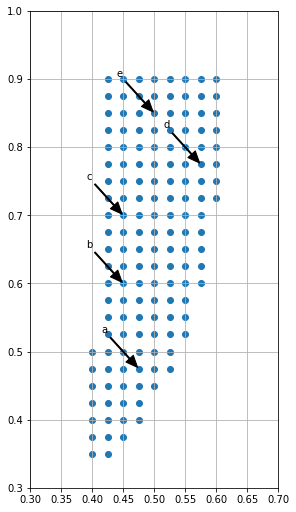

In [6]:
ind = [21, 49, 77, 105, 126]
str_ind = ['a', 'b', 'c', 'd', 'e']

fig1, ax = plt.subplots(constrained_layout=True, figsize = (4,7) )
ax.scatter(ext_exc, ext_inh)
ax.set_xlim(0.3, 0.7)
ax.set_ylim(0.3, 1.)
#ext_exc[ind[i]], ext_inh[ind[i]]

for i in range(len(ind)):
    x_ = ext_exc[ind[i]]
    y_ = ext_inh[ind[i]]
    ax.annotate(str_ind[i], xy=(x_, y_),  xycoords='data',
            xytext=(x_ - 0.05, y_ + 0.05), textcoords='data',
            arrowprops=dict(facecolor='black', shrink=0.03, headwidth=10, width=1),
            horizontalalignment='right', verticalalignment='bottom',
            )
    
    
plt.savefig( os.path.join(os.getcwd(), 'examples') )

In [7]:
data.set_parameters(aln)
case = '00000'
readpath = '.' + os.sep + 'data' + os.sep + str(case[:5]) + os.sep
control_data = data.read_control(readpath, case)

grid_resolution = layout.grid_resolution

amp_range = np.arange(6, 10, 1.)
start_range = np.arange(0., 40, 5)
#dur_range = np.arange(0, 50, 10)

weights = [1., 0., 1.]
mincost = np.zeros(len(ind))
mincost[:] = 1000.
minind = np.zeros(( len(ind), 3 ))
optcost = np.zeros(len(ind))
dist_ = np.zeros(len(ind))
DC_control = [None] * len(ind)

trans_time = 0.8

for i in range(len(ind)):
    
    print(ext_exc[ind[i]], ext_inh[ind[i]])
    
    dist_[i] = data.dist_right(ext_exc[ind[i]], ext_inh[ind[i]], ext_exc, ext_inh, grid_resolution)
    
    opt_cntrl = control_data[2][ind[i]][:,:,100:-100]
    opt_cost_node = control_data[4][ind[i]]
    optcost[i] = opt_cost_node[0][0][0] + opt_cost_node[2][0][0]

    for a in amp_range:
        print(a)
        for start in start_range:
            for dur in np.arange(0, 80 - start, 5):
                cost_DC, control_DC = data.DC_trace(aln, ext_exc[ind[i]], ext_inh[ind[i]], start, dur,
                                        [a * dist_[i],0], 100., case, trans_time, weights,
                                         opt_cntrl, opt_cost_node, weights)
                total_cost = ( weights[0] * cost_DC[0][0][0] + weights[1] * sum(cost_DC[1][0][:])
                              + weights[2] * sum(cost_DC[2][0][:]) )
                #print(a, start, dur, total_cost)
                if total_cost < mincost[i]:
                    minind[i] = [a, start, dur]
                    mincost[i] = total_cost
                    DC_control[i] = control_DC
                    #print("minimal index = ", a, start, dur)

    print('minimal cost = ', mincost[i], ' for indices = ', minind[i])

0.47500000000000014 0.4750000000000002
6.0
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17068.886839794224
Gradient descend method:  None
RUN  1 , total integrated cost =  3577.1403210487624
RUN  2 , total integrated cost =  1001.4210407298151
RUN  2 , total integrated cost =  1001.4210407298151
Improved over  2  iterations in  15.047229500000014  seconds by  94.13306180930843  percent.


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


Problem in initial value trasfer:  Vmean_exc -56.68528413861232 -56.68546410530506
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17069.66835799188
Gradient descend method:  None
RUN  1 , total integrated cost =  3580.2383598674846
RUN  2 , total integrated cost =  976.6357136646316
RUN  2 , total integrated cost =  976.6357136646316
Improved over  2  iterations in  0.07396260000001575  seconds by  94.27853140915079  percent.
Problem in initial value trasfer:  Vmean_exc -56.68528596994649 -56.68546589246001


ERROR:root:Problem in initial value trasfer


set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17069.943059782945
Gradient descend method:  None
RUN  1 , total integrated cost =  3572.680434717899
RUN  2 , total integrated cost =  871.2223338770923
RUN  2 , total integrated cost =  871.2223338770923
Improved over  2  iterations in  0.06581320000003643  seconds by  94.89616145276017  percent.
Problem in initial value trasfer:  Vmean_exc -56.68355605790955 -56.68382460668437
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17070.11834582501
Gradient descend method:  None
RUN  1 , total integrated cost =  3562.0740704665345
RUN  2 

...

 1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  19006.2861496294
Gradient descend method:  None
RUN  1 , total integrated cost =  10.800948752170346
RUN  2 , total integrated cost =  8.11276641664465
RUN  2 , total integrated cost =  8.11276641664465
Improved over  2  iterations in  0.08764450000001034  seconds by  99.95731535160117  percent.
Problem in initial value trasfer:  Vmean_exc -56.69258121459904 -56.69257979451524


ERROR:root:Problem in initial value trasfer


set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  18376.48567079931
Gradient descend method:  None
RUN  1 , total integrated cost =  7.016348735963531
RUN  2 , total integrated cost =  6.614976425820755
RUN  2 , total integrated cost =  6.614976425820755
Improved over  2  iterations in  0.09899270000005345  seconds by  99.96400303875113  percent.
Problem in initial value trasfer:  Vmean_exc -56.6924812795821 -56.69248392149404


ERROR:root:Problem in initial value trasfer


set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  274.50294586411405
Gradient descend method:  None
RUN  1 , total integrated cost =  6.849977551808989
RUN  2 , total integrated cost =  6.663678833062845
RUN  2 , total integrated cost =  6.663678833062845
Improved over  2  iterations in  0.09554609999997865  seconds by  97.57245634938958  percent.
Problem in initial value trasfer:  Vmean_exc -56.69251058117183 -56.69251177118488
minimal cost =  6.3639991018423245  for indices =  [ 8.  0. 50.]


0.47500000000000014 0.4750000000000002
EXAMPLE  1
DC minimal cost =  3.1048860413386796  for indices =  [ 7.  0. 50.]
Optimal cost =  2.885170796844945
DC higher by   7.615328864897775
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  3.104886041338647
Gradient descend method:  None
RUN  1 , total integrated cost =  3.0947206787868335
RUN  2 , total integrated cost =  3.092620328983417
RUN  3 , total integrated cost =  3.091072051609568
RUN  4 , total integrated cost =  3.0896796450413304
RUN  5 , total integrated cost =  3.088294500114058
RUN  6 , total integrated cost =  3.086951647667396
RUN  7 , total integrated cost =  3.0855830655528593
RUN  8 , total integrated cost =  3.084250957202045
RUN  9 , total integrated cost =  3.0828993083542735
RUN  10 , total integrated cost =  3.0815790569248014
RUN  11 , total integrated cost =  3.0802272024707387
RUN  12 , total integrated cost =  3.0788830603951824
RUN  13 , total integrated cos

RUN  100 , total integrated cost =  7.624990730192327
RUN  110 , total integrated cost =  7.617701423044806
RUN  120 , total integrated cost =  7.6144322857913
RUN  130 , total integrated cost =  7.609733190374711
RUN  140 , total integrated cost =  7.607495483597701
RUN  150 , total integrated cost =  7.6047590145430775
RUN  160 , total integrated cost =  7.601022002764107
RUN  170 , total integrated cost =  7.595372726009104
RUN  180 , total integrated cost =  7.591815327176163
RUN  190 , total integrated cost =  7.589734612818207
RUN  200 , total integrated cost =  7.58810316295703
RUN  300 , total integrated cost =  7.557514035048349
RUN  400 , total integrated cost =  7.540158681492496
RUN  500 , total integrated cost =  7.521852608771089
RUN  600 , total integrated cost =  7.506355963940284
RUN  700 , total integrated cost =  7.498011705693414
RUN  800 , total integrated cost =  7.495039550932716
RUN  900 , total integrated cost =  7.492242225123752
RUN  1000 , total integrated c

RUN  1500 , total integrated cost =  5.794242079881466
RUN  1600 , total integrated cost =  5.79414290064218
RUN  1700 , total integrated cost =  5.7940448479921045
RUN  1800 , total integrated cost =  5.793942770254932
RUN  1900 , total integrated cost =  5.793881722477263
RUN  2000 , total integrated cost =  5.793806387995853
RUN  2000 , total integrated cost =  5.793806387995853
Improved over  2000  iterations in  75.47297890000004  seconds by  8.959660501545414  percent.
10.149554237058549


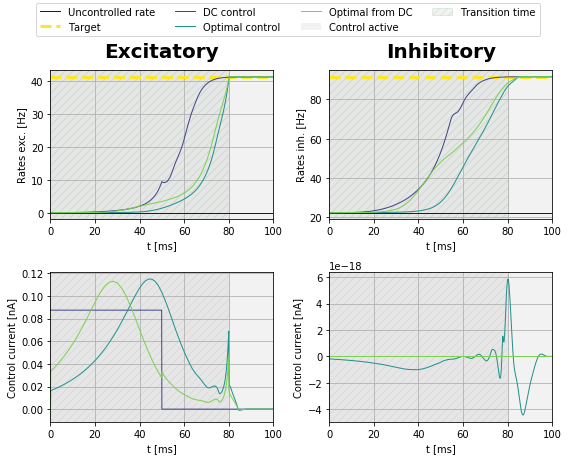

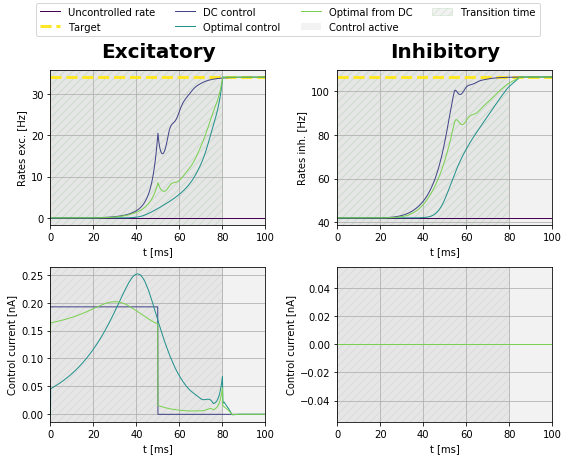

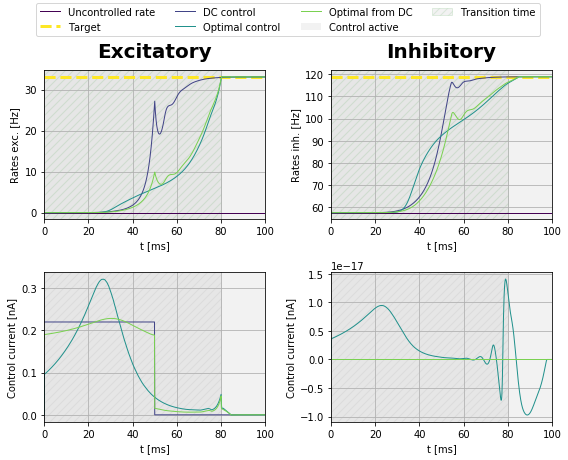

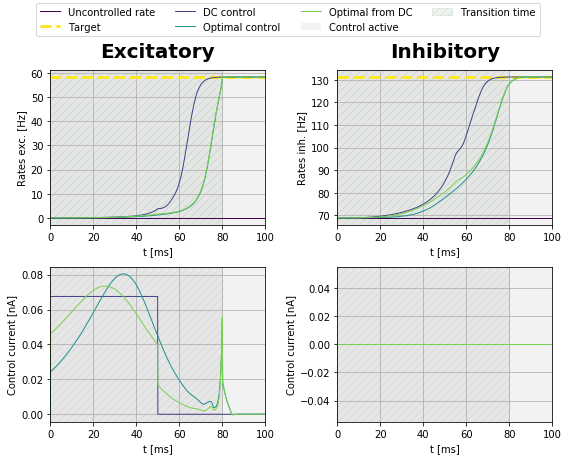

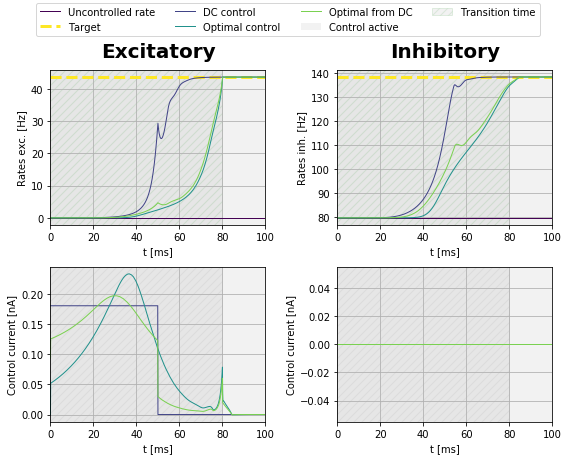

In [15]:
av_perc = 0.

for i in range(len(ind)):
    
    print(ext_exc[ind[i]], ext_inh[ind[i]])    
    opt_cntrl = control_data[2][ind[i]][:,:,100:-100]
    opt_cost_node = control_data[4][ind[i]]

    print("EXAMPLE ", i+1 )
    print('DC minimal cost = ', mincost[i], ' for indices = ', minind[i])
    print('Optimal cost = ', optcost[i])
    print('DC higher by  ', 100*( mincost[i]/optcost[i] - 1) )
    av_perc += 100 * ( mincost[i]/optcost[i] - 1)
    data.DC_trace(aln, ext_exc[ind[i]], ext_inh[ind[i]], minind[i][1], minind[i][2], [minind[i][0] * dist_[i],0],
                100., case, trans_time, weights, opt_cntrl, opt_cost_node, weights, plot_=True, max_it = 3000)
    
print(av_perc/5.)

In [29]:
data.set_parameters(aln)
case = '00001'
readpath = '.' + os.sep + 'data' + os.sep + str(case[:5]) + os.sep
control_data = data.read_control(readpath, case)

grid_resolution = layout.grid_resolution

amp_range = np.arange(6, 10, 1.)
start_range = np.arange(0., 20, 1)
#dur_range = np.arange(0, 50, 10)

weights = [1., 0., 1.]
mincost_400 = np.zeros(len(ind))
mincost_400[:] = 1000.
minind_400 = np.zeros(( len(ind), 3 ))
optcost_400 = np.zeros(len(ind))
dist__400 = np.zeros(len(ind))
DC_control_400 = [None] * len(ind)

trans_time = 0.8

for i in range(len(ind)):
    
    print(ext_exc[ind[i]], ext_inh[ind[i]])
    
    dist_[i] = data.dist_right(ext_exc[ind[i]], ext_inh[ind[i]], ext_exc, ext_inh, grid_resolution)
    
    opt_cntrl_400 = control_data[2][ind[i]][:,:,100:-100]
    opt_cost_node_400 = control_data[4][ind[i]]
    optcost_400[i] = opt_cost_node_400[0][0][0] + opt_cost_node_400[2][0][0]

    for a in amp_range:
        print(a)
        for start in start_range:
            for dur in np.arange(20, 80, 5):
                cost_DC, control_DC = data.DC_trace(aln, ext_exc[ind[i]], ext_inh[ind[i]], start, dur,
                                        [a * dist_[i],0], 400., case, trans_time, weights,
                                         opt_cntrl_400, opt_cost_node_400, weights)
                total_cost = ( weights[0] * cost_DC[0][0][0] + weights[1] * sum(cost_DC[1][0][:])
                              + weights[2] * sum(cost_DC[2][0][:]) )
                #print(a, start, dur, total_cost)
                if total_cost < mincost_400[i]:
                    minind_400[i] = [a, start, dur]
                    mincost_400[i] = total_cost
                    DC_control_400[i] = control_DC
                    #print("minimal index = ", a, start, dur)

    print('minimal cost = ', mincost_400[i], ' for indices = ', minind_400[i])

0.47500000000000014 0.4750000000000002
6.0
7.0
8.0
9.0
minimal cost =  2.9348392204684863  for indices =  [ 7.  0. 45.]
0.4500000000000001 0.6000000000000003
6.0
7.0
8.0
9.0
minimal cost =  6.778066649126417  for indices =  [ 9.  1. 30.]
0.4500000000000001 0.7000000000000004
6.0
7.0
8.0
9.0
minimal cost =  7.759923082737395  for indices =  [ 7.  0. 65.]
0.5750000000000002 0.7750000000000005
6.0
7.0
8.0
9.0
minimal cost =  2.1962325696519667  for indices =  [ 7.  0. 70.]
0.5000000000000002 0.8500000000000005
6.0
7.0
8.0
9.0
minimal cost =  6.037383539249436  for indices =  [ 8.  0. 45.]


0.47500000000000014 0.4750000000000002
EXAMPLE  1
DC minimal cost =  2.9348392204684863  for indices =  [ 7.  0. 45.]
Optimal cost =  2.7218587902907103
DC higher by   7.824815561244769
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  2.9348392204684863
Gradient descend method:  None
RUN  1 , total integrated cost =  2.9284915642184757
RUN  2 , total integrated cost =  2.9282931999606476
RUN  3 , total integrated cost =  2.928281755868851
RUN  4 , total integrated cost =  2.9282811002177733
RUN  5 , total integrated cost =  2.928281055514306
RUN  6 , total integrated cost =  2.928281053651647
RUN  7 , total integrated cost =  2.9282810536290107
RUN  8 , total integrated cost =  2.92828105362871
RUN  9 , total integrated cost =  2.928281053628382
RUN  10 , total integrated cost =  2.928281053628024
RUN  11 , total integrated cost =  2.928281053627584
RUN  12 , total integrated cost =  2.928281053627018
RUN  13 , total integrated cost 

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  53 , total integrated cost =  2.8215426168962514
Improved over  53  iterations in  5.72724240000025  seconds by  3.8604023955407456  percent.
Problem in initial value trasfer:  Vmean_exc -56.687522597204044 -56.687522629371436
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  2.7218461778983003
Gradient descend method:  None
RUN  1 , total integrated cost =  2.6984086778985557
RUN  2 , total integrated cost =  2.6983020745723616
RUN  3 , total integrated cost =  2.698299153980767
RUN  4 , total integrated cost =  2.698299141959636
RUN  5 , total integrated cost =  2.698299023798746
RUN  6 , total integrated cost =  2.6982989287505674
RUN  7 , total integrated cost =  2.698298867579254
RUN  8 , total integrated cost =  2.6982987894913206
RUN  9 , total integrated cost =  2.698298780718932
RUN  10 , total integrated cost =  2.698298729864712
RUN  11 , total integrated cost =  2.698298694225957
RUN  12 , total integrated cost =  

ERROR:root:Problem in initial value trasfer


RUN  70 , total integrated cost =  6.338303224152785
Control only changes marginally.
RUN  71 , total integrated cost =  6.338303224152785
Improved over  71  iterations in  7.102715900000476  seconds by  6.488036305017914  percent.
Problem in initial value trasfer:  Vmean_exc -56.66231672847907 -56.66231649494488
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  6.047204780107882
Gradient descend method:  None
RUN  1 , total integrated cost =  6.031579784645216
RUN  2 , total integrated cost =  6.031514262907679
RUN  3 , total integrated cost =  6.031514009723203
RUN  4 , total integrated cost =  6.031509290138941
RUN  5 , total integrated cost =  6.031508212586129
RUN  6 , total integrated cost =  6.031508155206269
RUN  7 , total integrated cost =  6.0315080764771665
RUN  8 , total integrated cost =  6.031508070151927
RUN  9 , total integrated cost =  6.031506872435127
RUN  10 , total integrated cost =  6.031505794377276
RUN  11 , total integrated cost =  6.03150

...

Control only changes marginally.
RUN  506 , total integrated cost =  7.4101262932367655
Improved over  506  iterations in  46.614171299999725  seconds by  4.507735267103129  percent.
Problem in initial value trasfer:  Vmean_exc -56.658058187567 -56.65805817484988
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  10966.473659004103
Gradient descend method:  None
RUN  1 , total integrated cost =  10959.746614328795
RUN  2 , total integrated cost =  7.870964107264634
RUN  3 , total integrated cost =  7.8632182851151
RUN  4 , total integrated cost =  7.861943024858962
RUN  5 , total integrated cost =  7.860812081222716
RUN  6 , total integrated cost =  7.859668776763596
RUN  7 , total integrated cost =  7.858510962822336
RUN  8 , total integrated cost =  7.8574355726448255
RUN  9 , total integrated cost =  7.856391688555838
RUN  10 , total integrated cost =  7.855351786304602
RUN  11 , total integrated cost =  7.854273736019621
RUN  12 , total integrated cost =  7.853

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  970 , total integrated cost =  6.86386710878335
Improved over  970  iterations in  90.8520621000007  seconds by  99.9374104445767  percent.
Problem in initial value trasfer:  Vmean_exc -56.65806318647739 -56.65806302619137
0.5750000000000002 0.7750000000000005
EXAMPLE  4
DC minimal cost =  2.1962325696519667  for indices =  [ 7.  0. 70.]
Optimal cost =  2.0242663639488065
DC higher by   8.495236040364752
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  2.1962325696519667
Gradient descend method:  None
RUN  1 , total integrated cost =  2.163029444651966
RUN  2 , total integrated cost =  2.162510645823818
RUN  3 , total integrated cost =  2.162508261638046
RUN  4 , total integrated cost =  2.16250820203341
RUN  5 , total integrated cost =  2.1625081988341033
RUN  6 , total integrated cost =  2.162508198818609
RUN  7 , total integrated cost =  2.162508198803382
RUN  8 , total integrated cost =  2.16

ERROR:root:Problem in initial value trasfer


RUN  190 , total integrated cost =  5.670829638490631
Control only changes marginally.
RUN  191 , total integrated cost =  5.670829638490631
Improved over  191  iterations in  18.90990790000069  seconds by  6.071403255662204  percent.
Problem in initial value trasfer:  Vmean_exc -56.692536169511484 -56.69253602385401
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5.508661886851826
Gradient descend method:  None
RUN  1 , total integrated cost =  5.503290793101829
RUN  2 , total integrated cost =  5.50307718841094
RUN  3 , total integrated cost =  5.503076834939394
RUN  4 , total integrated cost =  5.503076833761445
RUN  5 , total integrated cost =  5.503076833745667
RUN  6 , total integrated cost =  5.503076833732325
RUN  7 , total integrated cost =  5.503076833606327
RUN  8 , total integrated cost =  5.503076832848063
RUN  9 , total integrated cost =  5.503076832766589
RUN  10 , total integrated cost =  5.503076832753556
RUN  11 , total integrated cost =  5.503

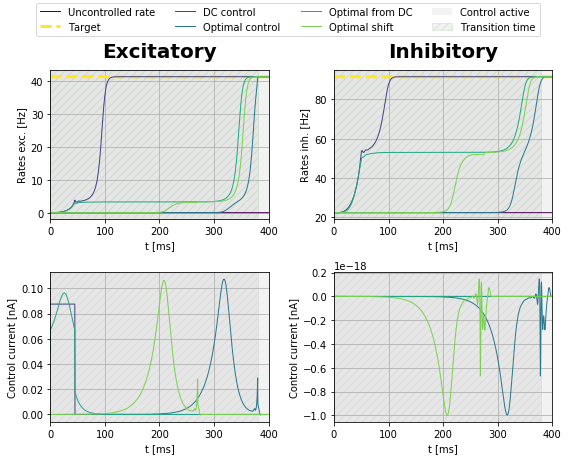

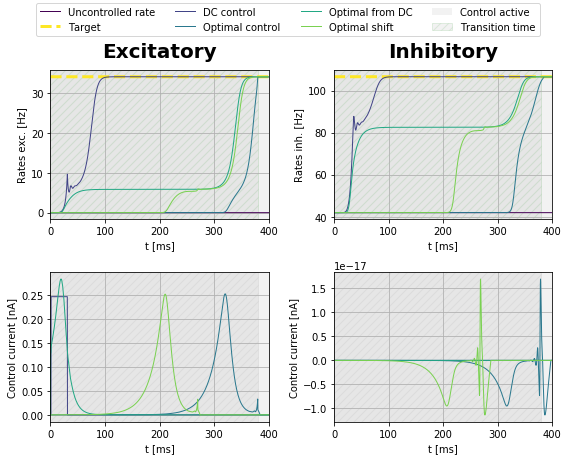

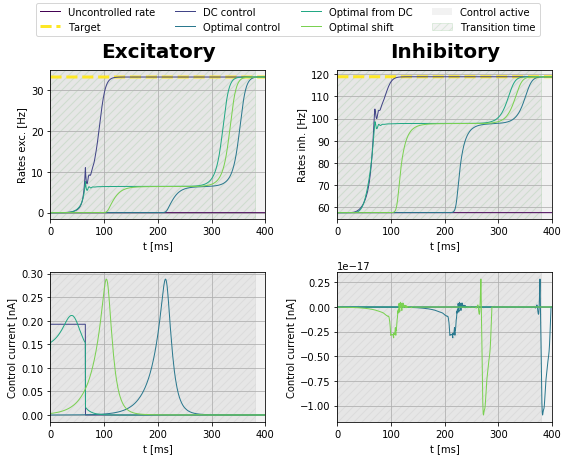

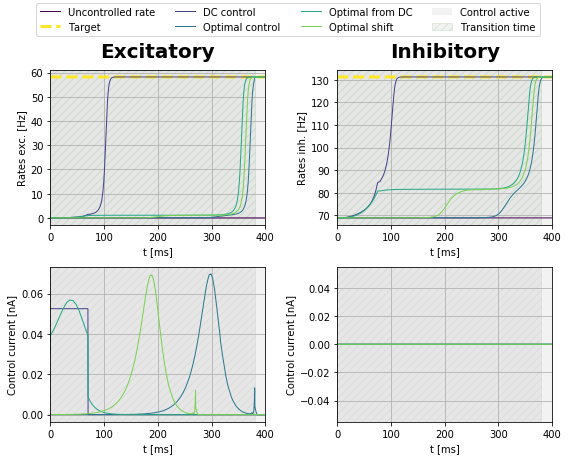

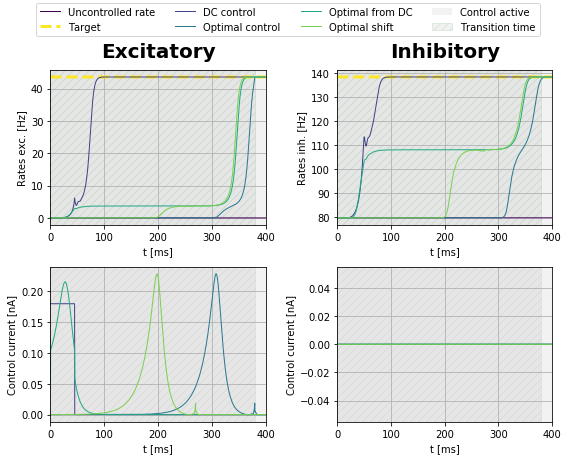

In [42]:
av_perc = 0.
trans_time = 0.95

for i in range(len(ind)):
    
    print(ext_exc[ind[i]], ext_inh[ind[i]])    
    opt_cntrl = control_data[2][ind[i]][:,:,100:-100]
    opt_cost_node = control_data[4][ind[i]]

    print("EXAMPLE ", i+1 )
    print('DC minimal cost = ', mincost_400[i], ' for indices = ', minind_400[i])
    print('Optimal cost = ', optcost_400[i])
    print('DC higher by  ', 100*( mincost_400[i]/optcost_400[i] - 1) )
    av_perc += 100 * ( mincost_400[i]/optcost_400[i] - 1)
    data.DC_trace(aln, ext_exc[ind[i]], ext_inh[ind[i]], minind_400[i][1], minind_400[i][2],
                  [minind_400[i][0] * dist_[i],0],
                400., case, trans_time, weights, opt_cntrl, opt_cost_node, weights, plot_=True, max_it = 10000 )
    
    
print(av_perc/5.)

In [24]:
opt_cntrl_100_b = [None] * len(ind)
opt_cntrl_400_b = [None] * len(ind)
cost_node_100_b = [None] * len(ind)
cost_node_400_b = [None] * len(ind)
opt_cntrl_100_m = [None] * len(ind)
opt_cntrl_400_m = [None] * len(ind)
cost_node_100_m = [None] * len(ind)
cost_node_400_m = [None] * len(ind)

target_100 = [None] * len(ind)
target_400 = [None] * len(ind)

initVars = [None] * len(ind)

case = '00000'
readpath = '.' + os.sep + 'data' + os.sep + str(case[:5]) + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind)):
    opt_cntrl_100_b[i] = control_data[2][ind[i]]
    cost_node_100_b[i] = control_data[4][ind[i]]
    
case = '00000max'
readpath = '.' + os.sep + 'data' + os.sep + str(case[:5]) + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind)):
    opt_cntrl_100_m[i] = control_data[2][ind[i]]
    cost_node_100_m[i] = control_data[4][ind[i]]
    
case = '00001'
readpath = '.' + os.sep + 'data' + os.sep + str(case[:5]) + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind)):
    opt_cntrl_400_b[i] = control_data[2][ind[i]]
    cost_node_400_b[i] = control_data[4][ind[i]]

case = '00001max'
readpath = '.' + os.sep + 'data' + os.sep + str(case[:5]) + os.sep
control_data = data.read_control(readpath, case)
for i in range(len(ind)):
    opt_cntrl_400_m[i] = control_data[2][ind[i]]
    cost_node_400_m[i] = control_data[4][ind[i]]
    
case = '00000'
readpath = '.' + os.sep + 'data' + os.sep + str(case[:5]) + os.sep

data.set_parameters(aln)

for i in range(len(ind)):
    
    
    print("------- ", i, ext_exc[ind[i]], ext_inh[ind[i]])
    aln.params.mue_ext_mean = ext_exc[ind[i]] * 5.
    aln.params.mui_ext_mean = ext_inh[ind[i]] * 5.
    
    aln.params.duration = 3000.
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = 3.)
    aln.run(control=control0)
    
    target_rates = np.zeros((2))
    target_rates[0] = aln.rates_exc[0,-1] 
    target_rates[1] = aln.rates_inh[0,-1]
    
    control0 = functions.step_control(aln, maxI_ = -3.)
    aln.run(control=control0)

    init_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            init_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            init_state_vars[j] = aln.state[state_vars[j]][0,-1]

    initVars[i] = init_state_vars
    
    aln.params.duration = 100.

    target_100[i] = aln.getZeroTarget()
    target_100[i][:,0,:] = target_rates[0]
    target_100[i][:,1,:] = target_rates[1]
    
    aln.params.duration = 400.

    target_400[i] = aln.getZeroTarget()
    target_400[i][:,0,:] = target_rates[0]
    target_400[i][:,1,:] = target_rates[1]

-------  0 0.47500000000000014 0.4750000000000002
-------  1 0.4500000000000001 0.6000000000000003
-------  2 0.4500000000000001 0.7000000000000004
-------  3 0.5750000000000002 0.7750000000000005
-------  4 0.5000000000000002 0.8500000000000005


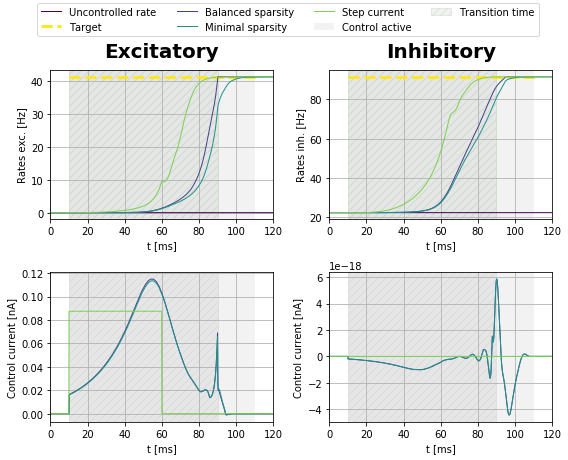

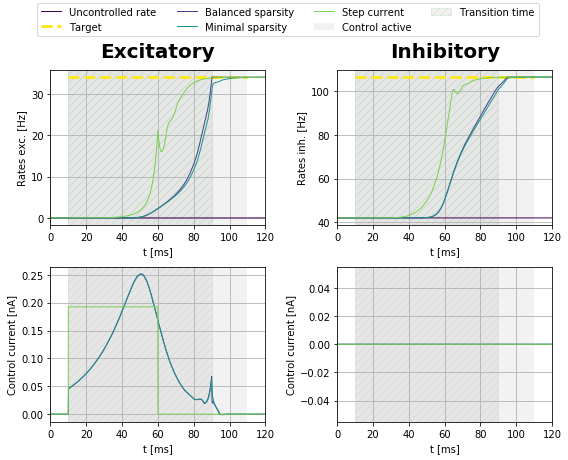

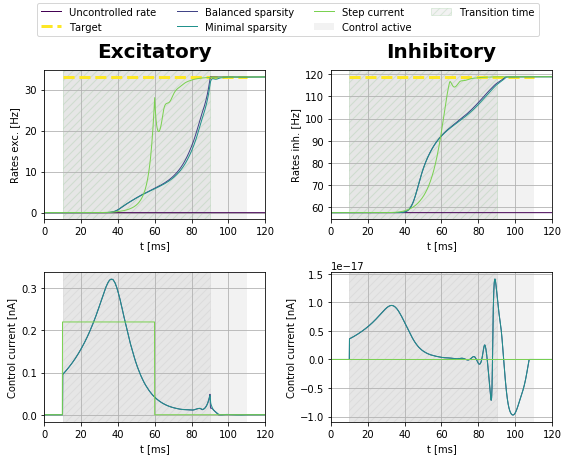

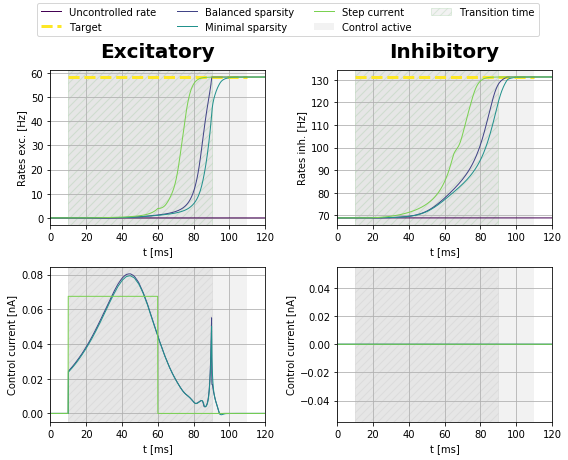

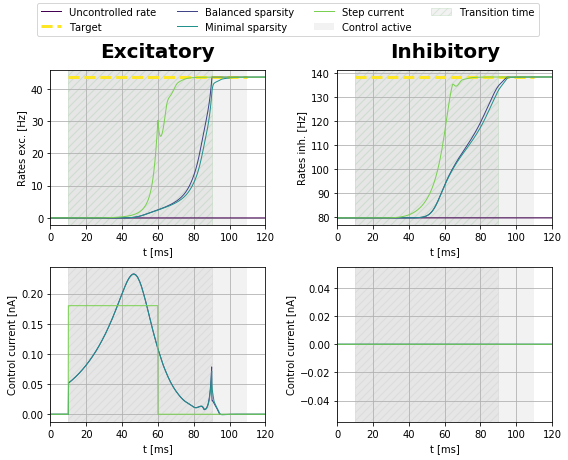

In [55]:
aln.params.duration = 100.
t_sim = aln.params.duration
t_sim_pre = 10.
t_sim_post = 10.

DC_control_shapeadjust = [None] * len(ind)

for i in range(len(ind)):
    aln.params.mue_ext_mean = ext_exc[ind[i]] * 5.
    aln.params.mui_ext_mean = ext_inh[ind[i]] * 5.
        
    DC_control_shapeadjust[i] = np.zeros(( opt_cntrl_100_b[i].shape ))
    DC_control_shapeadjust[i][:,:,100:-100] = DC_control[i].copy()
    DC_control_shapeadjust[i][:,:,-100:] = 0.
        
    plotFunc.plot_control_current(aln, [opt_cntrl_100_b[i], opt_cntrl_100_m[i], DC_control_shapeadjust[i]],
                                  [cost_node_100_b[i], cost_node_100_m[i], cost_node_100_m[i]],
                         [weights, weights, weights], t_sim, t_sim_pre, t_sim_post, initVars[i],
                         target_100[i], path_=os.getcwd(), filename_ = str(i) + '_100', shading = False, transition_time_ = 0.8,
                         labels_ = ['Balanced sparsity', 'Minimal sparsity', 'Step current'],
                         precision_variables_ = [0], print_cost_ = False)

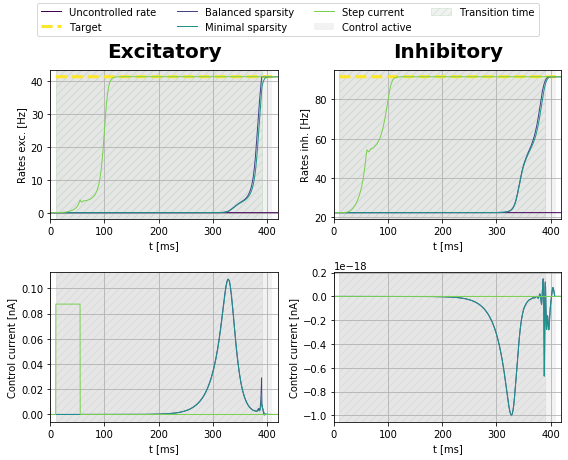

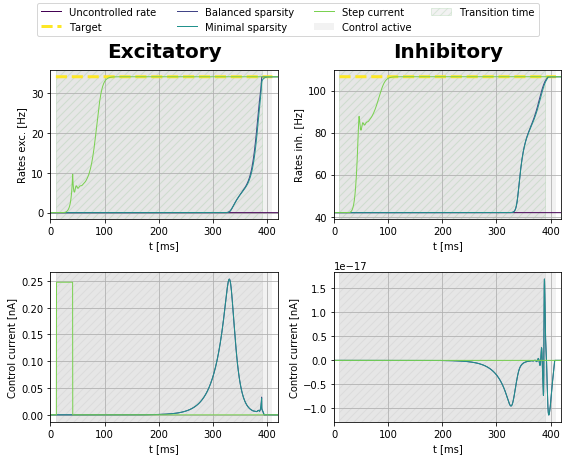

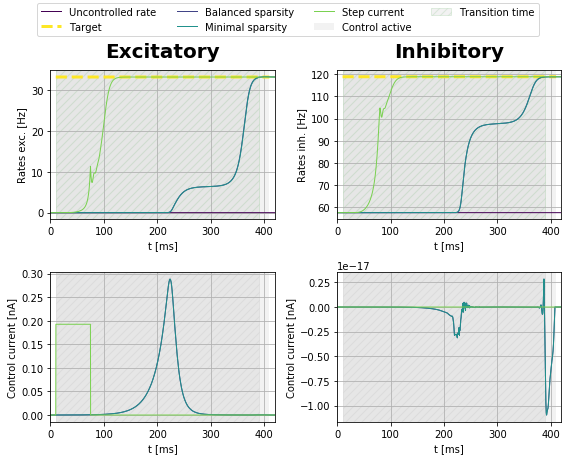

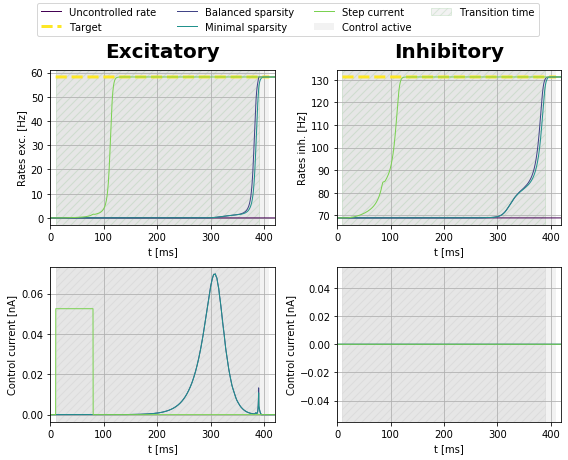

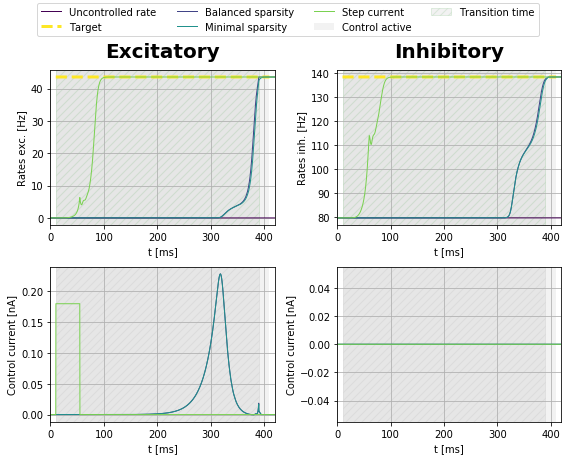

In [58]:
aln.params.duration = 400.
t_sim = aln.params.duration
data.set_parameters(aln)

DC_control_shapeadjust_400 = [None] * len(ind)

for i in range(len(ind)):
    aln.params.mue_ext_mean = ext_exc[ind[i]] * 5.
    aln.params.mui_ext_mean = ext_inh[ind[i]] * 5.
    
    DC_control_shapeadjust_400[i] = np.zeros(( opt_cntrl_400_b[i].shape ))
    DC_control_shapeadjust_400[i][:,:,100:-100] = DC_control_400[i].copy()
    DC_control_shapeadjust_400[i][:,:,-100:] = 0.
    
    plotFunc.plot_control_current(aln, [opt_cntrl_400_b[i], opt_cntrl_400_m[i], DC_control_shapeadjust_400[i]],
            [cost_node_400_b[i], cost_node_400_m[i]], [weights, weights], t_sim, t_sim_pre, t_sim_post, initVars[i],
                        target_400[i], path_=os.getcwd(), filename_ = str(i) + '_400', shading = False,
                        transition_time_ = 0.95, labels_ = ['Balanced sparsity', 'Minimal sparsity', 'Step current'],
                        precision_variables_ = [0], print_cost_ = False)